In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Concatenate, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample
import joblib
import time
from columns_check import columns_model

# Clean numeric columns
def clean_dataset(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].notnull().any():
            q_low = df_clean[col].quantile(0.001)
            q_high = df_clean[col].quantile(0.999)
            df_clean[col] = df_clean[col].clip(lower=q_low, upper=q_high)
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    return df_clean

# Load and preprocess data
file_path = '../../car_data_V_1_5_2026_01_14.csv'
# df = pd.read_csv(file_path)
df = columns_model(file_path)
df = clean_dataset(df)
print('cleaned df')
print(df.columns)
print(df.shape)
# Define categorical and numeric columns
categorical_cols = ['Combustible_DSL',
       'Combustible_ELT', 'Combustible_GAS', 'Combustible_GSL', 'Gama_Gama Alta', 'Gama_Gama Baja', 'Gama_Gama Media', 'Vitrina_venta_especial', 'Ubicacion_int', 'Descripcion_int', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int']
numeric_cols = [col for col in df.columns if col not in categorical_cols + ['Pricing']]

# Label encode categorical
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Target
y = np.log1p(df['Pricing']) / 50

# ---------------- BOOTSTRAP --------------------
df_bootstrap = df.copy()
df_bootstrap['Pricing'] = y  # y ya es log1p + escalado

df_bootstrap = resample(
    df_bootstrap,
    replace=True,
    n_samples=int(len(df_bootstrap) * 1.5),
    random_state=42
)
scaler = StandardScaler()
# Split variables nuevamente
y = df_bootstrap['Pricing']
X_cat = [df_bootstrap[col].values for col in categorical_cols]
X_num = scaler.fit_transform(df_bootstrap[numeric_cols])
# -----------------------------------------------

# Split después del bootstrapping
X_train_cat, X_test_cat, X_train_num, X_test_num, y_train, y_test = train_test_split(
    list(zip(*X_cat)), X_num, y, test_size=0.3, random_state=42
)


# Transponer X_cat nuevamente por columnas
X_train_cat = list(zip(*X_train_cat))
X_test_cat = list(zip(*X_test_cat))

# Preparar inputs para Keras
X_train = [np.array(col) for col in X_train_cat] + [X_train_num]
X_test = [np.array(col) for col in X_test_cat] + [X_test_num]


def build_embedding_model():
    inputs = []
    embeddings = []

    for col in categorical_cols:
        vocab_size = df[col].nunique() + 1
        embed_dim = min(50, (vocab_size + 1) // 2)
        input_i = Input(shape=(1,), name=col)
        embed_i = Embedding(input_dim=vocab_size, output_dim=embed_dim)(input_i)
        embed_i = Flatten()(embed_i)
        inputs.append(input_i)
        embeddings.append(embed_i)

    input_num = Input(shape=(X_num.shape[1],), name='numerical')
    inputs.append(input_num)
    x = BatchNormalization()(input_num)

    x = Concatenate()(embeddings + [x])
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    out = Dense(1)(x)

    model = Model(inputs=inputs, outputs=out)
    return model

# Compile and train
model = build_embedding_model()


c:\Users\manuel.torres\Modelos_Datacar\Datacarro_models\modelos_prueba\columns_check.py:26: DtypeWarning: Columns (2,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


['Unnamed: 0', 'Estado_vehiculo', 'Referencia_old', 'Fecha_venta', 'Modelo', 'Cod_fasecolda', 'Marca', 'Linea', 'Referencia', 'Kilometraje', 'Year', 'Month', 'Ubicacion', 'Ubicacion_int', 'MPIO_CDPMP', 'Servicio', 'Servicio_int', 'Estado_vitrina', 'Estado_vitrina_int', 'Gama', 'Gama_int', 'Group_number', 'Demanda', 'Sales', 'Promedio_estrellas', 'Combustible', 'Combustible_int', 'Descripcion_int', 'Blindaje', 'Estado_vehiculo_int', 'Pricing', 'Ref1']
(1497328, 16)
['Cod_fasecolda', 'Modelo', 'Kilometraje', 'Year', 'Month', 'Ubicacion_int', 'Demanda', 'Promedio_estrellas', 'Combustible', 'Descripcion_int', 'Gama', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int', 'Estado_vitrina', 'Pricing', 'Marca_cod', 'Tipolo_cod', 'Resto_cod']
(1497328, 19)
columns list: 
['Modelo', 'Kilometraje', 'Year', 'Month', 'Ubicacion_int', 'Demanda', 'Promedio_estrellas', 'Descripcion_int', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int', 'Pricing', 'Marca_cod', 'Tipolo_cod', 'Resto_cod', 'Combustible_DSL

In [2]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
decay_lr = tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3*0.985**x)
# X_train = np.array(X_train, dtype=np.float32)
# y_train = np.array(y_train, dtype=np.float32)

# tf.debugging.set_log_device_placement(True)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=128,
                    callbacks=[early_stop, decay_lr], verbose=1)

Epoch 1/100
9827/9827 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - loss: 0.0015 - mae: 0.0154 - mse: 0.0015 - val_loss: 4.9908e-05 - val_mae: 0.0051 - val_mse: 4.9908e-05 - learning_rate: 0.0010
Epoch 2/100
9827/9827 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 5.5078e-05 - mae: 0.0055 - mse: 5.5078e-05 - val_loss: 4.9008e-05 - val_mae: 0.0051 - val_mse: 4.9008e-05 - learning_rate: 9.8500e-04
Epoch 3/100
9827/9827 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 5.0368e-05 - mae: 0.0052 - mse: 5.0368e-05 - val_loss: 4.1535e-05 - val_mae: 0.0046 - val_mse: 4.1535e-05 - learning_rate: 9.7023e-04
Epoch 4/100
9827/9827 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 4.8014e-05 - mae: 0.0051 - mse: 4.8014e-05 - val_loss: 3.9070e-05 - val_mae: 0.0045 - val_mse: 3.9070e-05 - learning_rate: 9.5567e-04
Epoch 5/100
9827/9827 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 4.6577e-05 - mae: 0.0050 - mse: 4.6577e-05 - val_loss: 3.7257e-05 - val_mae: 0.0044 - val_mse: 3.7257e-05 - learning_rate: 9.4134e-04
Epoch 6/100
9827/9827 

In [3]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch 
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,learning_rate,epoch
51,0.000038,0.004440,0.000038,0.000034,0.004166,0.000034,0.000463,51
52,0.000038,0.004438,0.000038,0.000034,0.004185,0.000034,0.000456,52
53,0.000038,0.004435,0.000038,0.000033,0.004114,0.000033,0.000449,53
54,0.000038,0.004429,0.000038,0.000035,0.004285,0.000035,0.000442,54
55,0.000038,0.004430,0.000038,0.000034,0.004211,0.000034,0.000436,55


In [4]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch 

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error')
    plt.plot(hist['epoch'], hist['mse'], 'r--', label='Trainign Error')
    plt.plot(hist['epoch'], hist['val_mse'], 'b', label='Validation Error')
    plt.ylim([0,0.0001])
    plt.legend()
    plt.show()


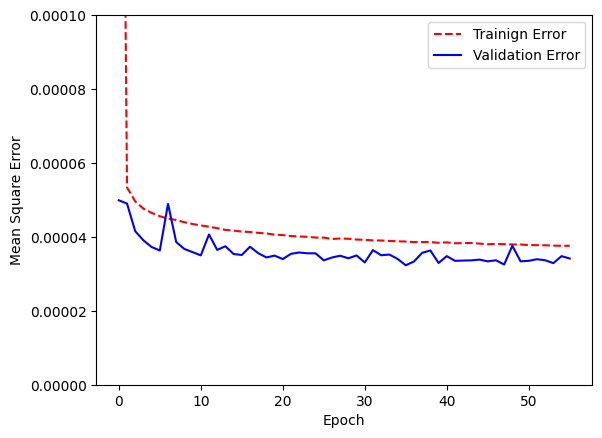

In [5]:
plot_history(history)

In [6]:
# X_test = np.array(X_test, dtype=np.float32)
# y_test = np.array(y_test, dtype=np.float32)
loss, mae, mse = model.evaluate(X_test, y_test, verbose=0)
print(f'Test MAE: {mae:.2f}, Test MSE: {mse:.2f}')


Test MAE: 0.00, Test MSE: 0.00


In [7]:
y_pred_log = model.predict(X_test, verbose=0)
y_pred = np.expm1(y_pred_log*50)
print(y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))

[[27266308.]
 [71882112.]
 [12954639.]
 ...
 [33560724.]
 [40757228.]
 [29400820.]]


In [8]:
print('rmse: ',rmse)
r2 = r2_score(y_test, y_pred_log)
print('R2: ', r2)

rmse:  0.005683206998434738
R2:  0.8164264432183495


In [9]:
model.save("../my_nn_model_pricing_6.keras")
joblib.dump(scaler, '../scaler_6.pkl')
# el 3 dio mejores resultados

['../scaler_6.pkl']

In [10]:
media = np.mean(y_test)
relative_error = rmse/media
print(relative_error)

0.016133788339022605


In [11]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, make_scorer, mean_absolute_error
mae = mean_absolute_error(y_test, y_pred_log)
relative_error_mae = mae / media
print(mae)
print(relative_error_mae)

0.004078357708529121
0.011577857371437019


In [12]:
joblib.dump(label_encoders, '../label_encoders_20260121.pkl')

['../label_encoders_20260121.pkl']